,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


<class 'pandas.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   class                     8124 non-null   str  
 1   cap-shape                 8124 non-null   str  
 2   cap-surface               8124 non-null   str  
 3   cap-color                 8124 non-null   str  
 4   bruises                   8124 non-null   str  
 5   odor                      8124 non-null   str  
 6   gill-attachment           8124 non-null   str  
 7   gill-spacing              8124 non-null   str  
 8   gill-size                 8124 non-null   str  
 9   gill-color                8124 non-null   str  
 10  stalk-shape               8124 non-null   str  
 11  stalk-root                8124 non-null   str  
 12  stalk-surface-above-ring  8124 non-null   str  
 13  stalk-surface-below-ring  8124 non-null   str  
 14  stalk-color-above-ring    8124 non-null   str  
 15

C:\Users\LEGION\AppData\Local\Temp\ipykernel_3196\3461770702.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='class', palette='Set2')


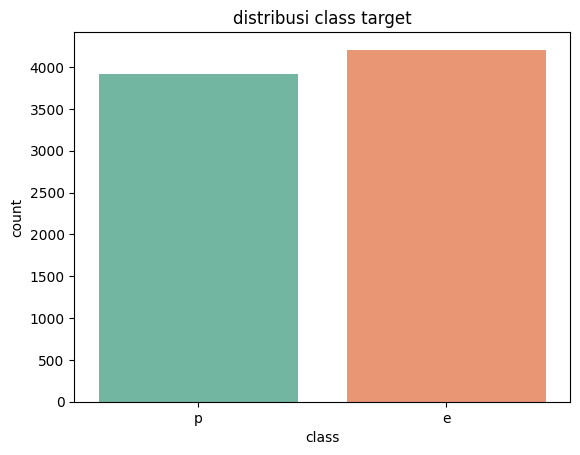

In [5]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, OneHotEncoder
from sklearn.naive_bayes import CategoricalNB, BernoulliNB, MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc

df = pd.read_csv('mushrooms.csv')
display(df.head())

df.info()
print("null count:\n", df.isnull().sum())

nu = df.nunique()
print("unik val:\n", nu)

sns.countplot(data=df, x='class', palette='Set2')
plt.title('distribusi class target')
plt.show()

In [6]:
df['stalk-root'] = df['stalk-root'].replace('?', 'missing')

drop_cols = nu[nu == 1].index.tolist()
if drop_cols: df.drop(columns=drop_cols, inplace=True)

X = df.drop(columns=['class'])
y = LabelEncoder().fit_transform(df['class'])

X_tr, X_ts, y_tr, y_ts = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X_tr_cat = oe.fit_transform(X_tr)
X_ts_cat = oe.transform(X_ts)

ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_tr_ohe = ohe.fit_transform(X_tr)
X_ts_ohe = ohe.transform(X_ts)

# intip output bentuk matriksnya
print("cat shape:", X_tr_cat.shape, "| ohe shape:", X_tr_ohe.shape)

cat shape: (6499, 21) | ohe shape: (6499, 116)


In [7]:
cnb = CategoricalNB().fit(X_tr_cat, y_tr)
pred_cnb, prob_cnb = cnb.predict(X_ts_cat), cnb.predict_proba(X_ts_cat)[:, 1]

bnb = BernoulliNB().fit(X_tr_ohe, y_tr)
pred_bnb, prob_bnb = bnb.predict(X_ts_ohe), bnb.predict_proba(X_ts_ohe)[:, 1]

mnb = MultinomialNB().fit(X_tr_ohe, y_tr)
pred_mnb, prob_mnb = mnb.predict(X_ts_ohe), mnb.predict_proba(X_ts_ohe)[:, 1]

,Model,Accuracy,Precision,Recall,F1-Score
0,Categorical NB,0.945846,0.990127,0.896552,0.941019
1,Bernoulli NB,0.932923,0.981429,0.877395,0.926500
2,Multinomial NB,0.945846,0.990127,0.896552,0.941019


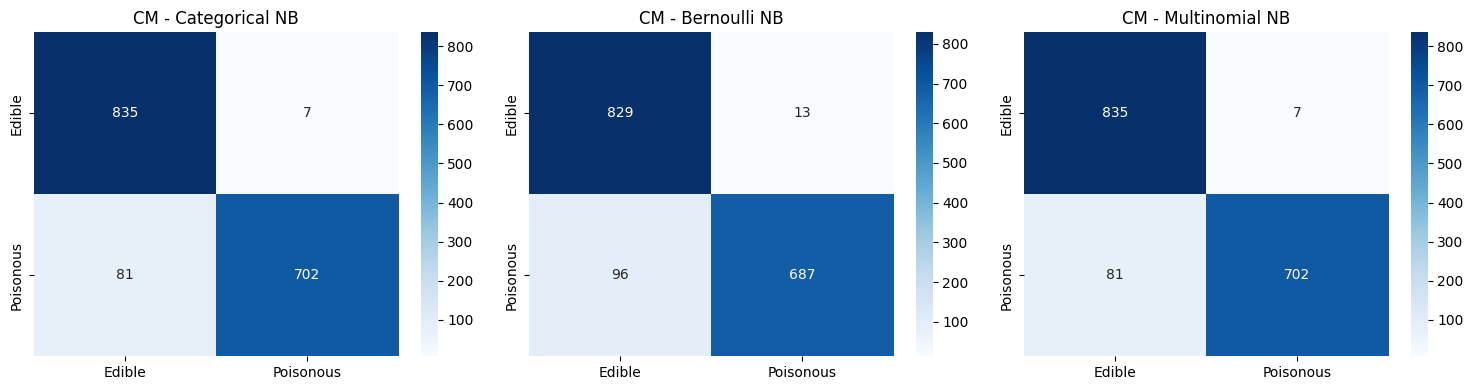

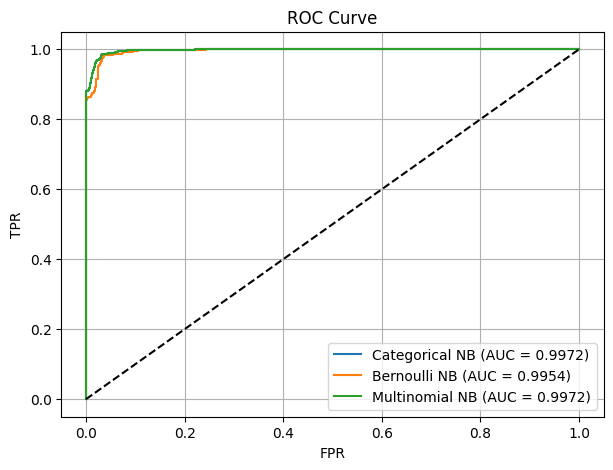

In [8]:
preds = [('Categorical NB', pred_cnb), ('Bernoulli NB', pred_bnb), ('Multinomial NB', pred_mnb)]
res = []
for name, p in preds:
    res.append({
        'Model': name,
        'Accuracy': accuracy_score(y_ts, p),
        'Precision': precision_score(y_ts, p),
        'Recall': recall_score(y_ts, p),
        'F1-Score': f1_score(y_ts, p)
    })
display(pd.DataFrame(res))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, p) in zip(axes, preds):
    sns.heatmap(confusion_matrix(y_ts, p), annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Edible', 'Poisonous'], yticklabels=['Edible', 'Poisonous'])
    ax.set_title(f'CM - {name}')
plt.tight_layout()
plt.show()

probs = [('Categorical NB', prob_cnb), ('Bernoulli NB', prob_bnb), ('Multinomial NB', prob_mnb)]
plt.figure(figsize=(7, 5))
for name, pr in probs:
    fpr, tpr, _ = roc_curve(y_ts, pr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc(fpr, tpr):.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title('ROC Curve'); plt.legend(); plt.grid(True)
plt.show()